In [1]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

from scipy.optimize import curve_fit

import dexplore as dx 
import xarray as xr
import os
import sys
import glob
import re
from pathlib import Path

sys.path.append(os.path.abspath("steele-lab-analysis-functions"))
import analysis_functions.core as af
from analysis_functions.users.pacome._format_data_xarray import format_data_xarray

from cavity_analysis import cavity_analysis
from cavity_theory import cavity_modes

model = af.ComplexCircle()

Loading BokehJS ...

In [2]:
dx.refresh_bokeh()

Loading BokehJS ...

In [3]:
base_folder = '/home/jovyan/steelelab/measurement_data/4KDIY/Pacome/SH_full_0001'
base_folder = '/home/jovyan/BACKUP/Pacome/SH_full_0001'

In [4]:
fc = 9.30154207e+09
fm = 1.21e+06 + 881

## VNA tuning

In [64]:
def find_folders(base_folder):
    parent = Path(base_folder)
    
    return [str(d) for d in parent.iterdir() if d.is_dir() and d.name.endswith('_VNA_tuning')]

Dropping dummy coordinate/dimension 0: "Cavity length (mm)"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']
Dropping dummy coordinate/dimension 0: "Cavity length (mm)"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']
Dropping dummy coordinate/dimension 0: "Cavity length (mm)"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']
Dropping dummy coordinate/dimension 0: "Cavity length (mm)"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']
Dropping dummy coordinate/dimension 0: "Cavity length (mm)"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']
Dropping dummy coordinate/dimension 0: "Cavity length (mm)"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']
Dropping dummy coordinate/dimension 0: "Cavity length (mm)"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']
Dropping dummy coordinate/dimension 0: "Cavity length (

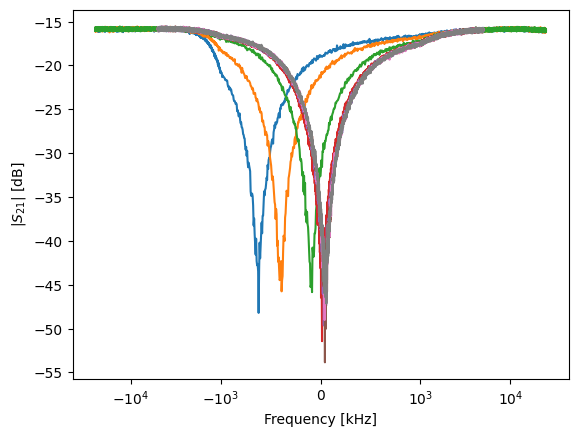

In [97]:
list_dir = find_folders(base_folder)
# The first folder is the cavity map

for full_path in list_dir[1:]:
    h5_files = sorted(glob.glob(full_path + '/*.h5'))
    
    data = xr.load_dataset(h5_files[0])

    translator = {'Frequency (Hz)':['freq', 'GHz', 1e9]}

    _data = format_data_xarray(data, tool='VNA', translator=translator)
    plt.plot((np.array(_data.freq.values) - _data.freq.values[len(_data.freq.values)//2])*1e6, _data.mag.values)
    plt.xscale('symlog', linthresh=1e3)
    plt.xlabel('Frequency [kHz]')
    plt.ylabel('$|S_{21}|$ [dB]')
plt.show()

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
Removing edelay: -18.498728265030 * (2*pi*freq) + 1075.109173087947
Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
Removing edelay: -15.822890804280 * (2*pi*freq) + 919.138311491825
Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
Removing edelay: -16.874955653832 * (2*pi*freq) + 980.459877809697
Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
Removing edelay: -10.829046536840 * (2*pi*freq) + 633.442565524371
Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
Removing edelay: -10.480803458320 * (2*pi*freq) + 613.100853058907
Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
Removing edelay: -33.221864236324 * (2*pi*freq) + 1941.452327517099
Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
R

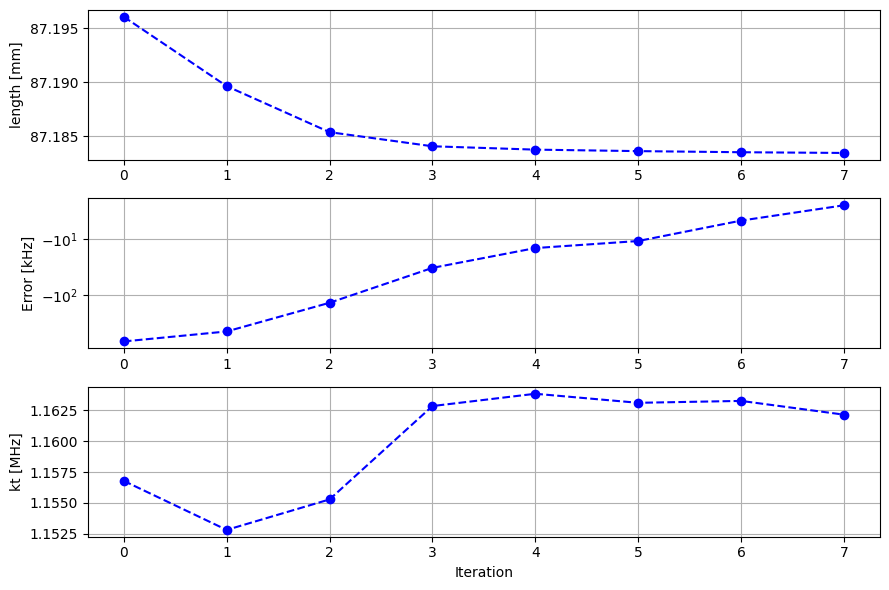

In [110]:
model = af.ComplexCircle()
main_params = {'f0': [], 'kt': [], 'length': []}

for full_path in list_dir[1:]:
    h5_files = sorted(glob.glob(full_path + '/*.h5'))
    
    data = xr.load_dataset(h5_files[0])

    translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
                  'Cavity length (mm)': ['length', 'mm', 1]}

    _data = format_data_xarray(data,
                               tool='VNA',
                               translator=translator,
                               remove_edelay = [0, 50, 0, 0])
    main_params['length'].append(_data.length.values[0])
    _data_fit = _data.isel(length = 0)
    fit_result = af.fit_single(model,
                               _data_fit.freq.values,
                               _data_fit.cpx.values,
                               guess = None)
    main_params['f0'].append(fit_result.params['f0'].value * 1e+09)
    main_params['kt'].append(fit_result.params['kt'].value * 1e+09)


fig = plt.figure(figsize=(9, 6))
gs = gridspec.GridSpec(3, 1)

axl = fig.add_subplot(gs[0, 0])
axf = fig.add_subplot(gs[1, 0])
axk = fig.add_subplot(gs[2, 0])

axl.plot(main_params['length'], 'bo--')
axl.set_ylabel('length [mm]')
axl.grid(True)
axf.plot((np.array(main_params['f0']) - fc)*1e-3, 'bo--')
axf.set_yscale('symlog', linthresh=10)
axf.set_ylabel('Error [kHz]')
axf.grid()
axk.plot(np.array(main_params['kt'])*1e-6, 'bo--')
axk.set_xlabel('Iteration')
axk.set_ylabel('kt [MHz]')
axk.grid(True)

fig.tight_layout()

## SA measurements

Dropping dummy coordinate/dimension 0: "power"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']


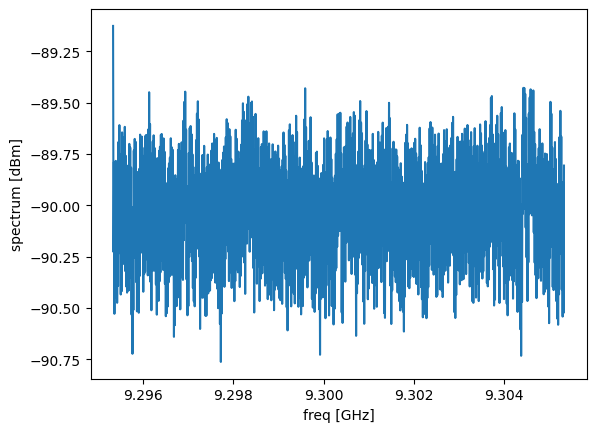

In [29]:
file_folder = '2026-06-24_12.12.25_0012_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9]}

background = format_data_xarray(data, tool='SA', translator=translator)
background.spect.plot()
plt.show()

Dropping dummy coordinate/dimension 0: "power"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']


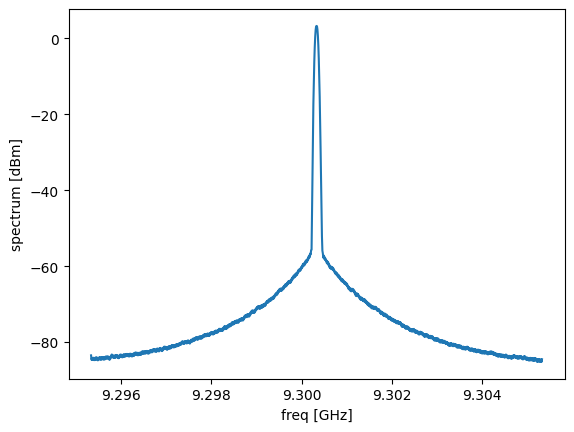

In [30]:
file_folder = '2026-06-24_12.10.27_0010_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9]}

source = format_data_xarray(data, tool='SA', translator=translator)
source.spect.plot()
plt.show()

Dropping dummy coordinate/dimension 0: "power"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']


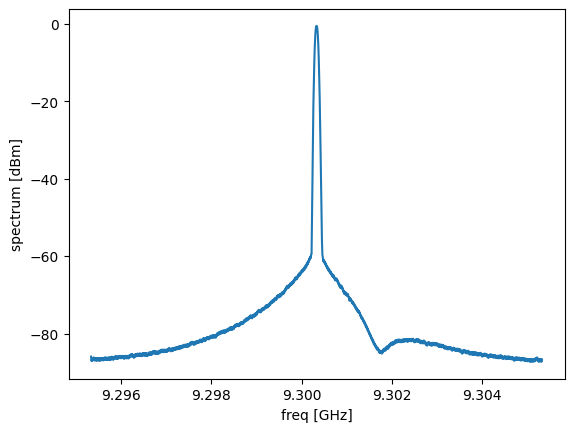

In [31]:
file_folder = '2026-06-24_12.11.29_0011_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9]}

cavity = format_data_xarray(data, tool='SA', translator=translator)
cavity.spect.plot()
plt.show()

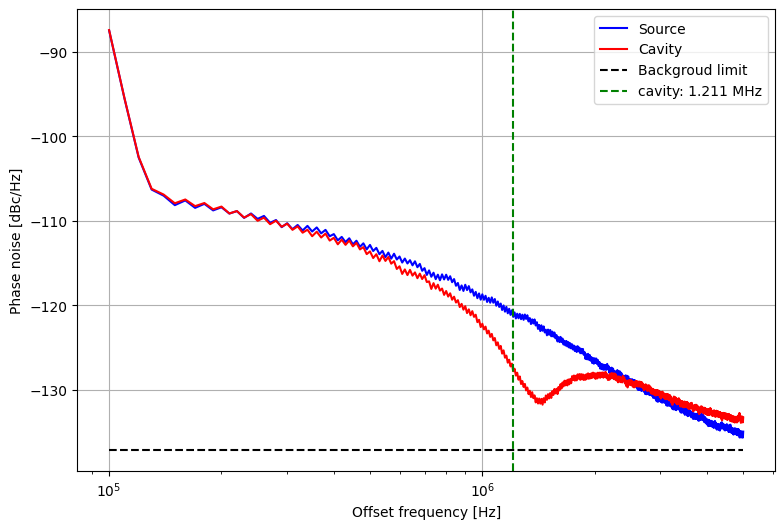

In [32]:
f0 = source.freq.values[np.argmax(source.spect.values)]

window = slice(f0 + 1e-4, source.freq.values[-1])
_source = source.sel(freq=window)
_cavity = cavity.sel(freq=window)
_background = background.sel(freq=window)

dBmmax_source = np.max(source.spect.values)
dBmmax_cavity = np.max(cavity.spect.values)
bandwidth = 51e+03

dBc_source = np.array(_source.spect.values) - dBmmax_source - 10*np.log10(bandwidth)
dBc_cavity = np.array(_cavity.spect.values) - dBmmax_cavity - 10*np.log10(bandwidth)
dBc_background = np.full(len(_background.freq.values), np.mean(background.spect.values)) - 10*np.log10(bandwidth)

plt.figure(figsize=(9,6))
plt.semilogx((np.array(_source.freq.values) - f0)*1e+09, dBc_source, color='blue', label='Source')
plt.semilogx((np.array(_cavity.freq.values) - f0)*1e+09, dBc_cavity, color='red', label='Cavity')
plt.semilogx((np.array(_background.freq.values) - f0)*1e+09, dBc_background, color='black', linestyle='--', label='Backgroud limit')
plt.axvline(fm, color='green', linestyle='--', label=f'cavity: {fm*1e-6:.3f} MHz')
plt.xlabel('Offset frequency [Hz]')
plt.ylabel('Phase noise [dBc/Hz]')
plt.legend()
plt.grid(True)
plt.show()

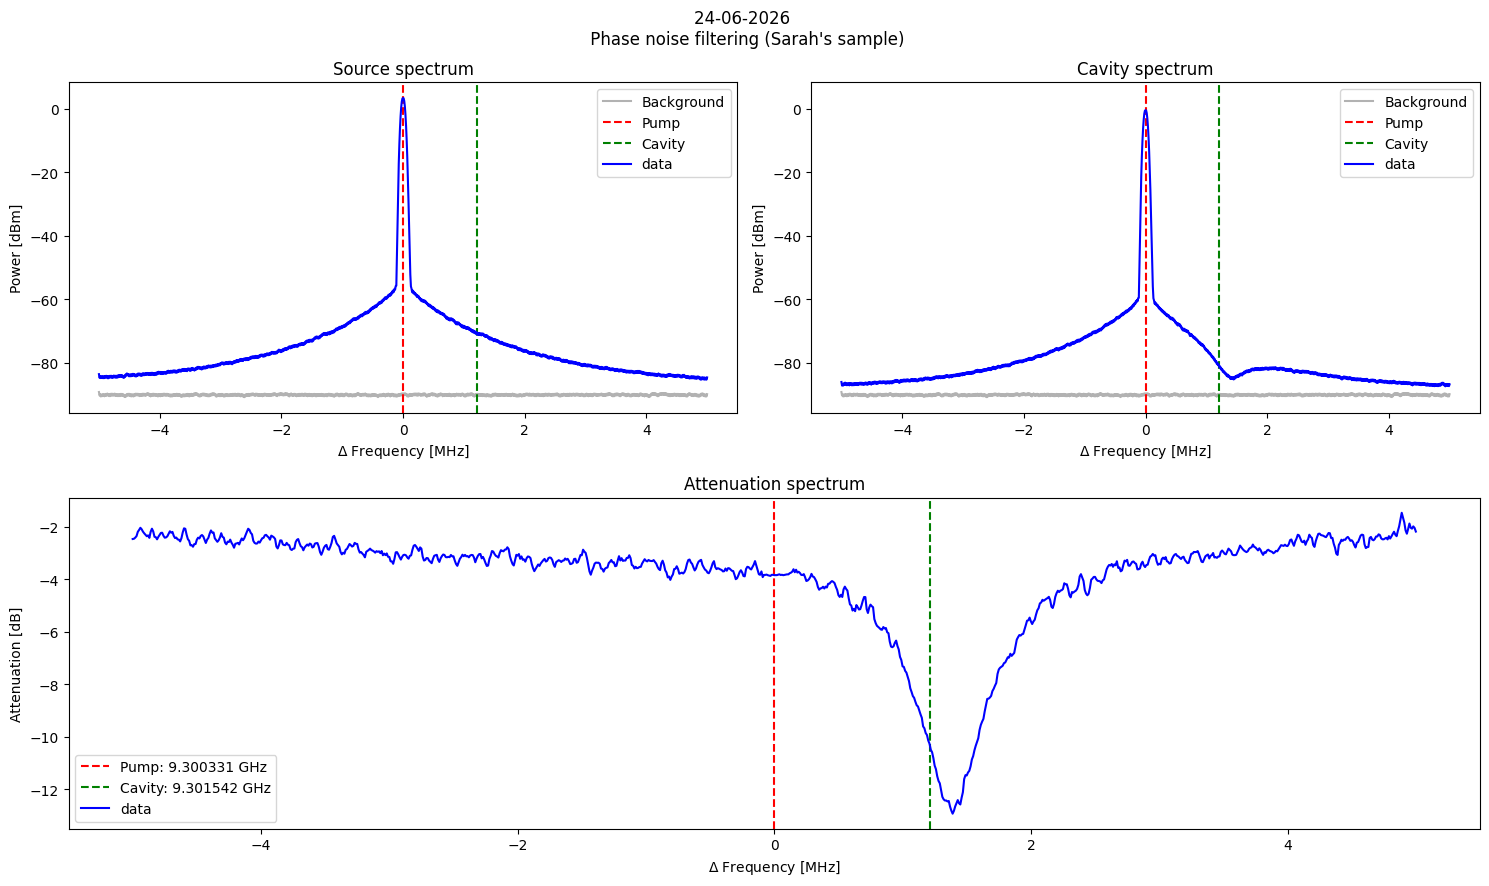

In [34]:
fig = plt.figure(figsize=(15, 9))
gs = gridspec.GridSpec(2, 2)

ax_source = fig.add_subplot(gs[0, 0])
ax_cavity = fig.add_subplot(gs[0, 1])
ax_att = fig.add_subplot(gs[1, :])

freq = source.freq.values
delta_freq = (freq - freq[len(freq)//2])*1e3 # MHz
dBm_background = background.spect.values
dBm_source = source.spect.values
dBm_cavity = cavity.spect.values

ymin = np.min(dBm_background) - 5
ymax = np.max(dBm_source) + 5

ax_source.plot(delta_freq, dBm_background, color='black', alpha = 0.3, label='Background')
ax_source.axvline(0, color='red', linestyle='--', label='Pump')
ax_source.axvline(fm * 1e-6, color='green', linestyle='--', label='Cavity')
ax_source.plot(delta_freq, dBm_source, color='blue', label='data')
ax_source.set_xlabel('$\Delta$ Frequency [MHz]')
ax_source.set_ylabel('Power [dBm]')
ax_source.set_ylim(ymin, ymax)
ax_source.set_title('Source spectrum')
ax_source.legend()

ax_cavity.plot(delta_freq, dBm_background, color='black', alpha = 0.3, label='Background')
ax_cavity.axvline(0, color='red', linestyle='--', label='Pump')
ax_cavity.axvline(fm * 1e-6, color='green', linestyle='--', label='Cavity')
ax_cavity.plot(delta_freq, dBm_cavity, color='blue', label='data')
ax_cavity.set_xlabel('$\Delta$ Frequency [MHz]')
ax_cavity.set_ylabel('Power [dBm]')
ax_cavity.set_ylim(ymin, ymax)
ax_cavity.set_title('Cavity spectrum')
ax_cavity.legend()

ax_att.axvline(0, color='red', linestyle='--', label=f'Pump: {(fc - fm)*1e-09:.6f} GHz')
ax_att.axvline(fm * 1e-6, color='green', linestyle='--', label=f'Cavity: {fc*1e-09:.6f} GHz')
ax_att.plot(delta_freq, dBm_cavity - dBm_source, color='blue', label='data')
ax_att.set_xlabel('$\Delta$ Frequency [MHz]')
ax_att.set_ylabel('Attenuation [dB]')
ax_att.set_title('Attenuation spectrum')
ax_att.legend()

fig.suptitle(f"24-06-2026 \n Phase noise filtering (Sarah's sample)")
fig.tight_layout()

## Last VNA trace

Dropping dummy coordinate/dimension 0: "Cavity length (mm)"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']


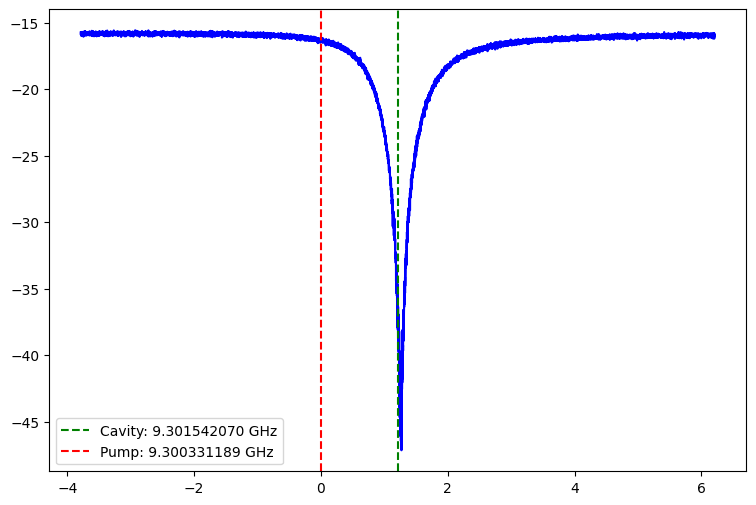

In [5]:
file_folder = '2026-06-24_11.41.27_0009_VNA_tuning'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=2)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9]}

vna = format_data_xarray(data, tool='VNA', translator=translator)
plt.figure(figsize=(9, 6))
plt.plot((np.array(vna.freq.values) - (fc - fm)*1e-09)*1e+03, vna.mag.values, color='blue')
plt.axvline(fm * 1e-06, color='green', linestyle='--', label=f'Cavity: {fc*1e-09:.9f} GHz')
plt.axvline(0, color='red', linestyle='--', label=f'Pump: {(fc - fm)*1e-09:.9f} GHz')
plt.legend()
plt.show()

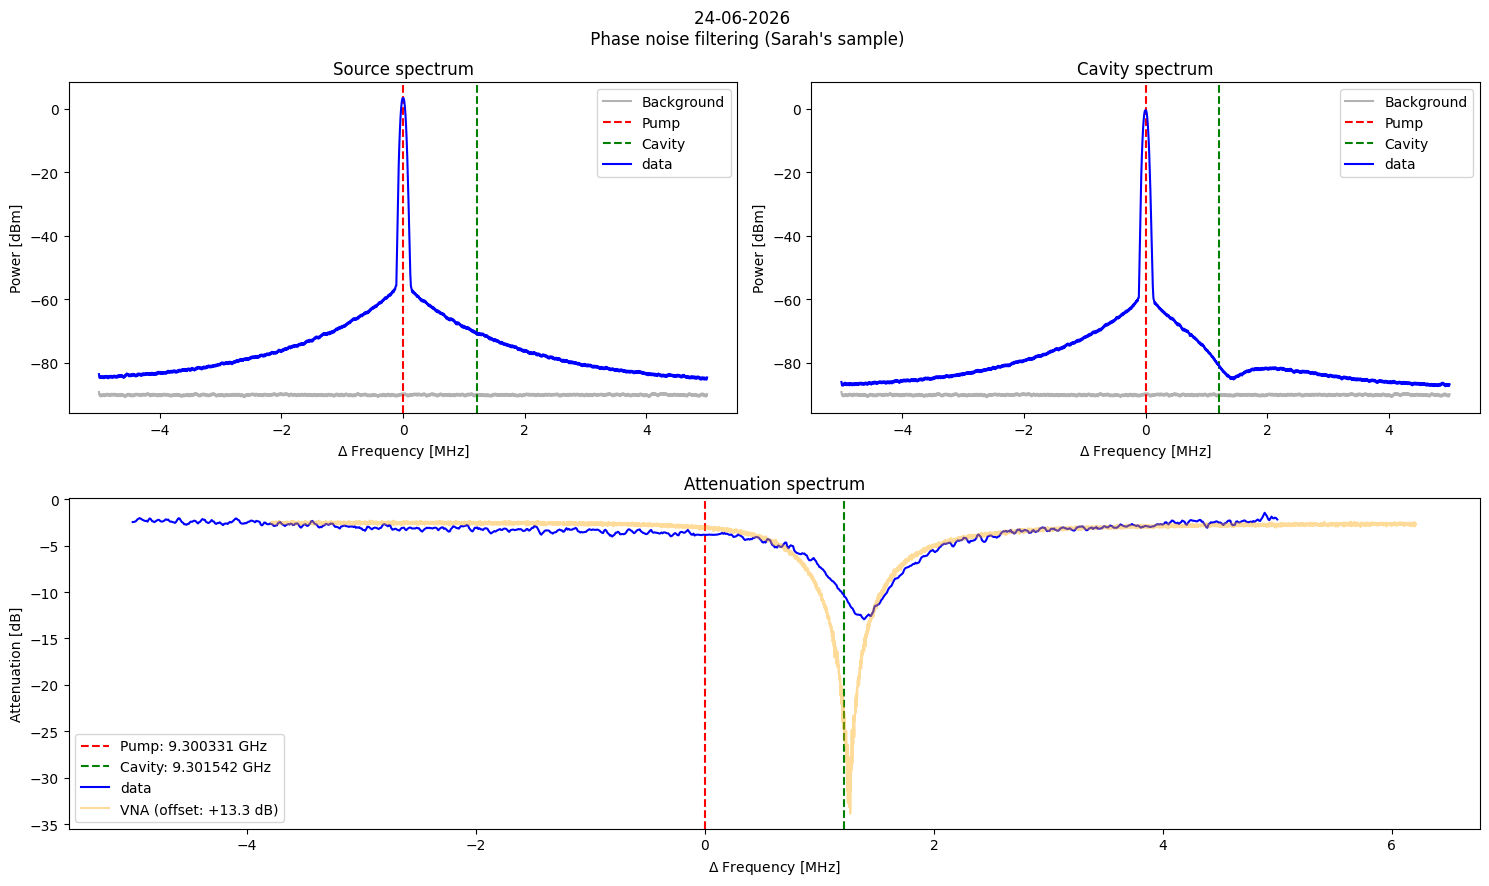

In [57]:
fig = plt.figure(figsize=(15, 9))
gs = gridspec.GridSpec(2, 2)

ax_source = fig.add_subplot(gs[0, 0])
ax_cavity = fig.add_subplot(gs[0, 1])
ax_att = fig.add_subplot(gs[1, :])

freq = source.freq.values
delta_freq = (freq - freq[len(freq)//2])*1e3 # MHz
dBm_background = background.spect.values
dBm_source = source.spect.values
dBm_cavity = cavity.spect.values

ymin = np.min(dBm_background) - 5
ymax = np.max(dBm_source) + 5

ax_source.plot(delta_freq, dBm_background, color='black', alpha = 0.3, label='Background')
ax_source.axvline(0, color='red', linestyle='--', label='Pump')
ax_source.axvline(fm * 1e-6, color='green', linestyle='--', label='Cavity')
ax_source.plot(delta_freq, dBm_source, color='blue', label='data')
ax_source.set_xlabel('$\Delta$ Frequency [MHz]')
ax_source.set_ylabel('Power [dBm]')
ax_source.set_ylim(ymin, ymax)
ax_source.set_title('Source spectrum')
ax_source.legend()

ax_cavity.plot(delta_freq, dBm_background, color='black', alpha = 0.3, label='Background')
ax_cavity.axvline(0, color='red', linestyle='--', label='Pump')
ax_cavity.axvline(fm * 1e-6, color='green', linestyle='--', label='Cavity')
ax_cavity.plot(delta_freq, dBm_cavity, color='blue', label='data')
ax_cavity.set_xlabel('$\Delta$ Frequency [MHz]')
ax_cavity.set_ylabel('Power [dBm]')
ax_cavity.set_ylim(ymin, ymax)
ax_cavity.set_title('Cavity spectrum')
ax_cavity.legend()

VNA_freq = np.array(vna.freq.values)
VNA_delta = (VNA_freq - freq[len(freq)//2])*1e3 # MHz

ax_att.axvline(0, color='red', linestyle='--', label=f'Pump: {(fc - fm)*1e-09:.6f} GHz')
ax_att.axvline(fm * 1e-6, color='green', linestyle='--', label=f'Cavity: {fc*1e-09:.6f} GHz')
ax_att.plot(delta_freq, dBm_cavity - dBm_source, color='blue', label='data')
ax_att.plot(VNA_delta, vna.mag.values - (vna.mag.values[0] - (dBm_cavity[0] - dBm_source[0])),
            color='orange', label=f'VNA (offset: +{-vna.mag.values[0] + (dBm_cavity[0] - dBm_source[0]):.1f} dB)', alpha = 0.4)
ax_att.set_xlabel('$\Delta$ Frequency [MHz]')
ax_att.set_ylabel('Attenuation [dB]')
ax_att.set_title('Attenuation spectrum')
ax_att.legend()

fig.suptitle(f"24-06-2026 \n Phase noise filtering (Sarah's sample)")
fig.tight_layout()

# Span 100 MHz

Dropping dummy coordinate/dimension 0: "power"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']


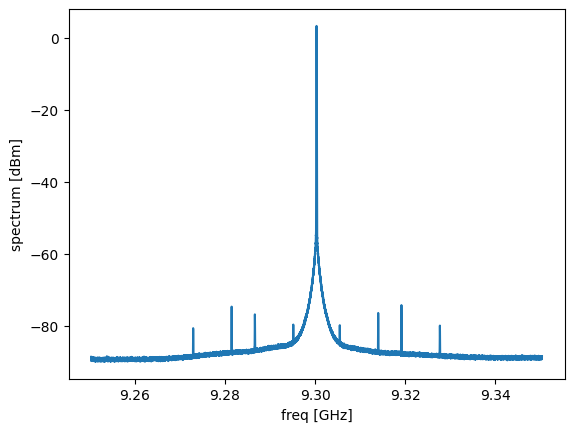

In [20]:
file_folder = '2026-06-24_14.20.36_0013_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9]}

source = format_data_xarray(data, tool='SA', translator=translator)
source.spect.plot()
plt.show()

Dropping dummy coordinate/dimension 0: "power"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']


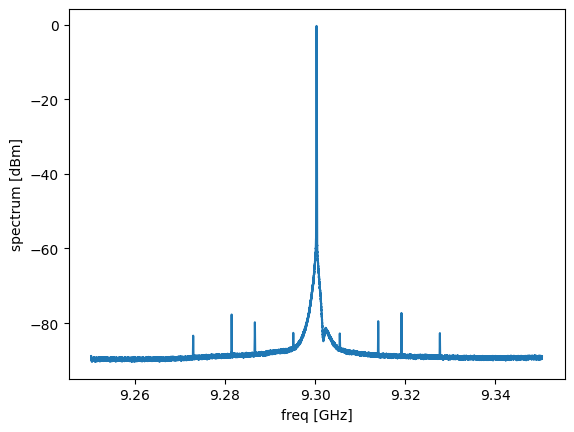

In [21]:
file_folder = '2026-06-24_14.22.02_0014_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9]}

cavity = format_data_xarray(data, tool='SA', translator=translator)
cavity.spect.plot()
plt.show()

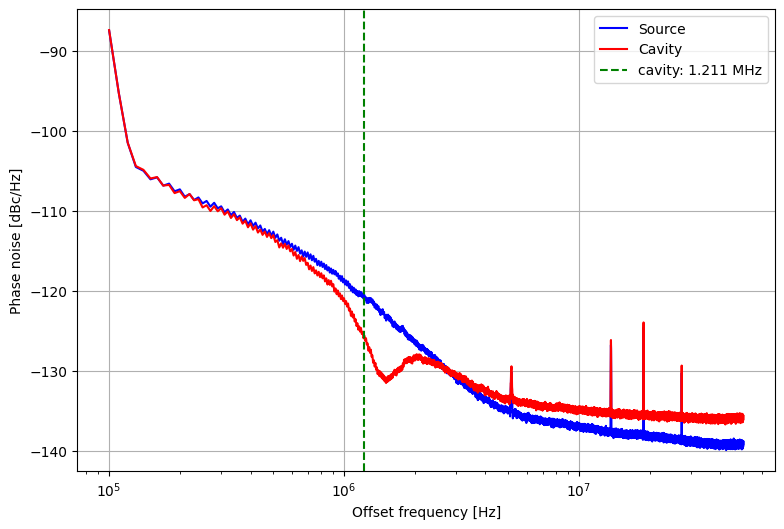

In [25]:
f0 = source.freq.values[np.argmax(source.spect.values)]

window = slice(f0 + 1e-4, source.freq.values[-1])
_source = source.sel(freq=window)
_cavity = cavity.sel(freq=window)

dBmmax_source = np.max(source.spect.values)
dBmmax_cavity = np.max(cavity.spect.values)
bandwidth = 51e+03

dBc_source = np.array(_source.spect.values) - dBmmax_source - 10*np.log10(bandwidth)
dBc_cavity = np.array(_cavity.spect.values) - dBmmax_cavity - 10*np.log10(bandwidth)

plt.figure(figsize=(9,6))
plt.semilogx((np.array(_source.freq.values) - f0)*1e+09, dBc_source, color='blue', label='Source')
plt.semilogx((np.array(_cavity.freq.values) - f0)*1e+09, dBc_cavity, color='red', label='Cavity')
plt.axvline(fm, color='green', linestyle='--', label=f'cavity: {fm*1e-6:.3f} MHz')
plt.xlabel('Offset frequency [Hz]')
plt.ylabel('Phase noise [dBc/Hz]')
plt.legend()
plt.grid(True)
plt.show()